# 07 — 1D Convolutional Autoencoder Baseline

A symmetric 1D-CNN autoencoder. Conv1D + MaxPool in the encoder, Conv1D +
UpSampling1D in the decoder. Trained on nominal windows only; scoring pipeline
mirrors NB 05 so the four baselines (IForest, PCA, LSTM-AE, CNN-AE) are
directly comparable.

**Inputs**: preprocessed arrays from `data/processed/` (built by NB 02)
**Outputs**: `submissions/cnn_ae.parquet`, `models/cnn_ae.keras`,
`data/processed/scores_val_cnn_ae.npy`, `data/processed/scores_test_cnn_ae.npy`

**Sections**
0. Setup & Imports
1. Load Data
2. Build and Train CNN-AE
3. Score Validation and Test — Channel-normalised reconstruction error
4. Threshold-Transfer Gate
5. Threshold Tuning — Tune / holdout split, corrected event-wise F0.5
6. Generate Test Predictions and Save Submission
7. Compare to all Baselines

## 0 — Setup & Imports

In [1]:
import sys, gc, json, time, os
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sentinel.ml_logic.data    import find_anomaly_segments
from sentinel.ml_logic.metrics import corrected_event_f05
from sentinel.params import (
    RANDOM_STATE, WINDOW_SIZE, TRAIN_RATIO,
    ANOMALY_COLOR, NOMINAL_COLOR,
)

tf.keras.utils.set_random_seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR   = Path('../data/processed')
MODELS_DIR      = Path('../models')
SUBMISSIONS_DIR = Path('../submissions')
RAW_DIR         = Path('../data/raw')
MODELS_DIR.mkdir(exist_ok=True)
SUBMISSIONS_DIR.mkdir(exist_ok=True)

print('TF', tf.__version__, '- GPUs:', tf.config.list_physical_devices('GPU'))

TF 2.16.2 - GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 1 — Load Data

Preprocessed windows and row arrays come from NB 02. All 58 channels stored in
the processed arrays are already the scored-target channels (the NB 02
preprocessor filters them before writing), so no further channel subsetting is
needed — we verify this against `target_channels.csv`.

In [2]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

SPLIT_IDX = cfg['split_idx']
WIN       = cfg['window_size']
N_FEAT    = cfg['n_features']
assert WIN == WINDOW_SIZE, f'window mismatch: {WIN} vs {WINDOW_SIZE}'

target_channels = pd.read_csv(RAW_DIR / 'target_channels.csv')['target_channels'].tolist()
assert len(target_channels) == N_FEAT, \
    f'target channel count {len(target_channels)} != processed n_features {N_FEAT}'
assert list(target_channels) == list(cfg['target_channels']), \
    'target channel order in preprocessing_config does not match target_channels.csv'

# Nominal windows used for training (+ fit-time val split)
X_train_nom = np.load(PROCESSED_DIR / 'X_train_nom.npy')
X_val_nom   = np.load(PROCESSED_DIR / 'X_val_nom.npy')

# Full labelled val split (with y) is the only source of anomalies for F0.5 tuning
X_all  = np.load(PROCESSED_DIR / 'train_full_scaled.npy')
y_all  = np.load(PROCESSED_DIR / 'y_train_row.npy')
X_val  = X_all[SPLIT_IDX:]
y_val  = y_all[SPLIT_IDX:]
del X_all, y_all; gc.collect()

X_test   = np.load(PROCESSED_DIR / 'test_scaled.npy')
test_ids = np.load(PROCESSED_DIR / 'test_ids.npy')

val_segments = find_anomaly_segments(y_val)
n_events     = len(val_segments)

print(f'X_train_nom   : {X_train_nom.shape}')
print(f'X_val_nom     : {X_val_nom.shape}')
print(f'X_val (row)   : {X_val.shape}   ({int(y_val.sum()):,} anomalous rows, {n_events} events)')
print(f'X_test (row)  : {X_test.shape}')
print(f'target channels: {len(target_channels)}  (all stored channels are scored)')

X_train_nom   : (105487, 100, 58)
X_val_nom     : (26354, 100, 58)
X_val (row)   : (2945665, 58)   (310,175 anomalous rows, 38 events)
X_test (row)  : (521280, 58)
target channels: 58  (all stored channels are scored)


---
## 2 — Build and Train CNN-AE

Symmetric Conv1D autoencoder. The encoder halves the time axis twice via
`MaxPool1D(2)` (100 -> 50 -> 25) and compresses to 8 channels at the bottleneck.
The decoder mirrors this with `UpSampling1D(2)` and a final linear `Conv1D` for
reconstruction. Compiled with Adam(1e-3) and MSE loss.

Each window is **z-normalised per-window before the forward pass**
(`zscore_window`) so the model reconstructs *shape* rather than magnitude —
this neutralises the scale drift between train and test that otherwise
dominates a non-linear reconstruction score (documented failure mode of NB 05
v1 and NB 07 v1 on Kaggle).

In [3]:
def build_cnn_ae(window_size, n_channels):
    inputs = layers.Input(shape=(window_size, n_channels))

    # Encoder
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(16, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D( 8, 3, activation='relu', padding='same')(x)   # bottleneck

    # Decoder
    x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    outputs = layers.Conv1D(n_channels, 7, activation='linear', padding='same')(x)

    model = Model(inputs, outputs, name='cnn_ae')
    model.compile(optimizer=Adam(1e-3), loss='mse')
    return model


model = build_cnn_ae(WIN, N_FEAT)
model.summary()

Model: "cnn_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 58)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 32)        │        13,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 16)         │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 25, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 58)        │        13,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,034 (125.13 KB)

 Trainable params: 32,034 (125.13 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)


EPOCHS     = 50
BATCH_SIZE = 256
MODEL_PATH = MODELS_DIR / 'cnn_ae.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=0),
]

X_train_norm = zscore_window(X_train_nom)

print(f'Training on {len(X_train_norm):,} z-normalised nominal windows (validation_split=0.1) ...')
t0 = time.time()
history = model.fit(
    X_train_norm, X_train_norm,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
    shuffle=True,
)
train_seconds = time.time() - t0
epochs_run    = len(history.history['loss'])
print(f'Trained in {train_seconds/60:.1f} min ({epochs_run} epochs)')
print(f'Model saved -> {MODEL_PATH}')
del X_train_norm; gc.collect()

Training on 105,487 z-normalised nominal windows (validation_split=0.1) ...


Epoch 1/50


371/371 - 44s - 118ms/step - loss: 0.7873 - val_loss: 0.7372 - learning_rate: 0.0010


Epoch 2/50


371/371 - 41s - 110ms/step - loss: 0.7281 - val_loss: 0.7149 - learning_rate: 0.0010


...

Epoch 50/50


371/371 - 38s - 102ms/step - loss: 0.6791 - val_loss: 0.6758 - learning_rate: 0.0010


Restoring model weights from the end of the best epoch: 50.


Trained in 126.9 min (50 epochs)
Model saved -> ../models/cnn_ae.keras


753

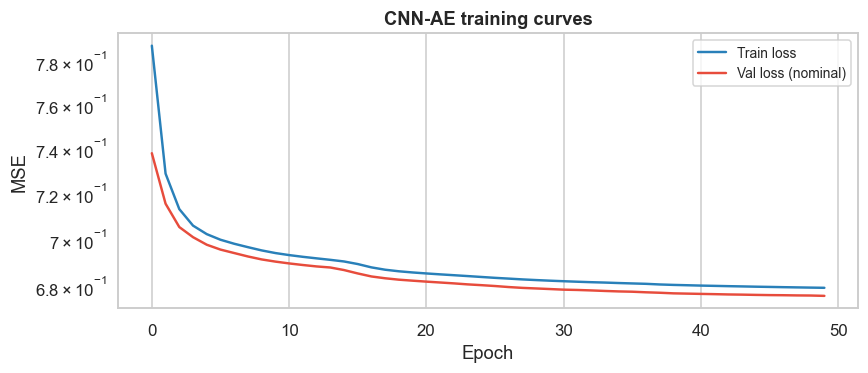

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
h = history.history
ax.plot(h['loss'],     color=NOMINAL_COLOR, lw=1.6, label='Train loss')
ax.plot(h['val_loss'], color=ANOMALY_COLOR, lw=1.6, label='Val loss (nominal)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_yscale('log')
ax.set_title('CNN-AE training curves', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 3 — Score Validation and Test — Top-k Channel MSE

One scalar per 100-row window, built in two steps: (1) z-normalise the window,
(2) compute per-channel MSE between the z-normalised window and its
reconstruction, then take the **mean of the top 5 channels**. Mean over all
58 channels dilutes a localised anomaly signal (most ESA-ADB anomalies touch
only a handful of telemetry streams); top-k preserves the per-channel signal.

Val and test windows are built by reshaping row arrays into non-overlapping
windows (stride = WINDOW_SIZE). Trailing rows that don't fill a full window
inherit the last window's score.

In [6]:
TOPK_CHANNELS = 5


def window_score(model, X, k=TOPK_CHANNELS, batch_size=256):
    '''Mean of the top-k per-channel MSE values, after per-window z-normalisation.'''
    Xn    = zscore_window(X)
    Xhat  = model.predict(Xn, batch_size=batch_size, verbose=0)
    per_c = ((Xn - Xhat) ** 2).mean(axis=1)          # (batch, channel) — MSE per channel
    topk  = np.partition(per_c, -k, axis=1)[:, -k:]  # (batch, k)
    return topk.mean(axis=1).astype(np.float32)


def make_windows(X_rows, win=WIN):
    n_full = len(X_rows) // win
    return X_rows[:n_full * win].reshape(n_full, win, X_rows.shape[1]), n_full


X_val_win,  n_val_win  = make_windows(X_val)
X_test_win, n_test_win = make_windows(X_test)

print(f'Scoring val  ({n_val_win:,} windows) ...')
t0 = time.time()
val_scores_win = window_score(model, X_val_win)
print(f'  {time.time()-t0:.1f}s')

print(f'Scoring test ({n_test_win:,} windows) ...')
t0 = time.time()
test_scores = window_score(model, X_test_win)
print(f'  {time.time()-t0:.1f}s')

# Pure-nominal diagnostic (held-out nominal windows)
nom_scores = window_score(model, X_val_nom)
print(f'Nominal diagnostic (X_val_nom, {len(nom_scores):,} windows): '
      f'median={np.median(nom_scores):.4f}  p99={np.quantile(nom_scores, 0.99):.4f}')

# Broadcast window scores to row level for val (needed for event-wise metric)
val_scores = np.repeat(val_scores_win, WIN)
if len(val_scores) < len(X_val):
    val_scores = np.concatenate([val_scores,
                                 np.full(len(X_val) - len(val_scores),
                                         val_scores_win[-1], dtype=np.float32)])

np.save(PROCESSED_DIR / 'scores_val_cnn_ae.npy',  val_scores)
np.save(PROCESSED_DIR / 'scores_test_cnn_ae.npy', test_scores)

print(f'val_scores  : {val_scores.shape}   range [{val_scores.min():.4f}, {val_scores.max():.4f}]')
print(f'test_scores : {test_scores.shape}  range [{test_scores.min():.4f}, {test_scores.max():.4f}]')

Scoring val  (29,456 windows) ...


  4.4s
Scoring test (5,212 windows) ...


  0.6s


Nominal diagnostic (X_val_nom, 26,354 windows): median=1.0386  p99=1.1160
val_scores  : (2945665,)   range [0.9999, 1.2369]
test_scores : (5212,)  range [0.9998, 1.1581]


---
## 4 — Threshold-Transfer Gate

Same diagnostic as NB 05 §4 — a large val/test max-score ratio is a warning
sign, not an automatic fail. The channel-normalised score is designed to be
more drift-robust than NB 05's raw MSE, so the ratio here should be smaller.

Val range  : 0.9999 ... 1.2369
Test range : 0.9998 ... 1.1581
Max ratio (val / test) : 1.1x


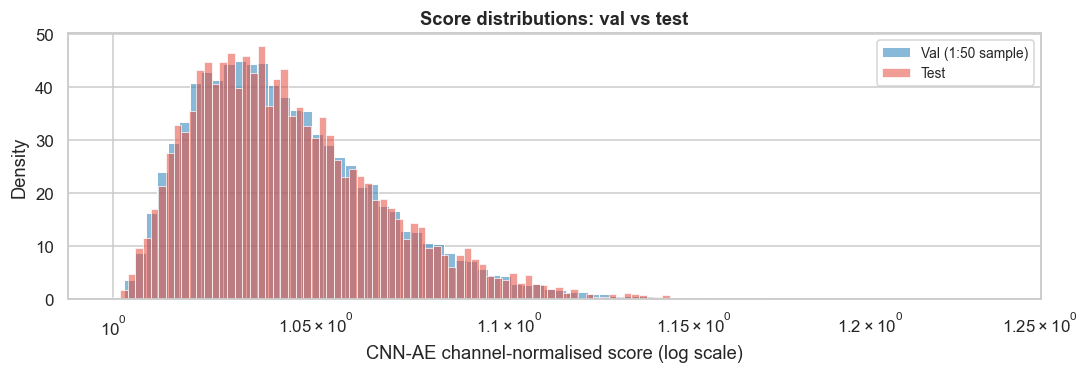

In [7]:
val_max  = float(val_scores.max())
test_max = float(test_scores.max())
ratio    = val_max / max(test_max, 1e-9)

print(f'Val range  : {val_scores.min():.4f} ... {val_max:.4f}')
print(f'Test range : {test_scores.min():.4f} ... {test_max:.4f}')
print(f'Max ratio (val / test) : {ratio:.1f}x')

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(val_scores[::50], ax=ax, color=NOMINAL_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val (1:50 sample)')
sns.histplot(test_scores,      ax=ax, color=ANOMALY_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Test')
ax.set_xlabel('CNN-AE channel-normalised score (log scale)')
ax.set_ylabel('Density')
ax.set_title('Score distributions: val vs test', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 5 — Threshold Tuning — Tune / Holdout Split

The labelled val is split into two contiguous temporal halves. Thresholds are
swept on the first half (tune) with corrected event-wise F0.5 as the objective;
the locked threshold is then evaluated on the second half (holdout) to check
for overfitting to the tune slice. A percentile-matched fallback (same as
NB 05 §5) is applied when the raw threshold falls outside the test range.

In [8]:
mid       = len(val_scores) // 2
tune_s    = val_scores[:mid]
tune_y    = y_val[:mid]
hold_s    = val_scores[mid:]
hold_y    = y_val[mid:]

tune_events = find_anomaly_segments(tune_y)
hold_events = find_anomaly_segments(hold_y)
print(f'Tune half   : {len(tune_s):,} rows, {int(tune_y.sum()):,} anomalous, {len(tune_events)} events')
print(f'Holdout half: {len(hold_s):,} rows, {int(hold_y.sum()):,} anomalous, {len(hold_events)} events')

candidates = np.quantile(tune_s, np.linspace(0.5, 0.999, 200))
f05_tune   = np.array([
    corrected_event_f05(tune_y, (tune_s > t).astype(np.int8))['f_score']
    for t in candidates
], dtype=np.float32)

peak_idx = int(np.argmax(f05_tune))
peak_t   = float(candidates[peak_idx])
peak_f05 = float(f05_tune[peak_idx])
print(f'Tune peak : threshold = {peak_t:.6f}  F0.5 = {peak_f05:.4f}')

# Holdout evaluation at the locked threshold
hold_pred   = (hold_s > peak_t).astype(np.int8)
hold_metric = corrected_event_f05(hold_y, hold_pred)
print(f'Holdout   : F0.5 = {hold_metric["f_score"]:.4f}   '
      f'(tp={hold_metric["tp_events"]}, fn={hold_metric["fn_events"]}, '
      f'fp_pred={hold_metric["fp_pred_events"]})')

# Full val (both halves) at the same threshold, as reference for the comparison
# table and so val_scores_threshold and test_scores_threshold share a derivation
full_pred   = (val_scores > peak_t).astype(np.int8)
full_metric = corrected_event_f05(y_val, full_pred)
full_f05    = float(full_metric['f_score'])
print(f'Full val  : F0.5 = {full_f05:.4f}   '
      f'(tp={full_metric["tp_events"]}, fn={full_metric["fn_events"]}, '
      f'fp_pred={full_metric["fp_pred_events"]})')


def apply_threshold_fallback(t, val_scores, test_scores):
    if test_scores.min() > t or test_scores.max() < t:
        q = float((val_scores <= t).mean())
        return float(np.quantile(test_scores, q)), q
    return float(t), None


applied_t, fallback_q = apply_threshold_fallback(peak_t, val_scores, test_scores)
if fallback_q is not None:
    print(f'Transfer gate failed - percentile fallback at q={fallback_q:.4f}, t={applied_t:.4f}')
else:
    print(f'Raw threshold transferred - using t={applied_t:.4f}')

Tune half   : 1,472,832 rows, 133,686 anomalous, 16 events
Holdout half: 1,472,833 rows, 176,489 anomalous, 22 events


Tune peak : threshold = 1.159166  F0.5 = 0.2499


Holdout   : F0.5 = 0.1110   (tp=2, fn=20, fp_pred=15)


Full val  : F0.5 = 0.1666   (tp=5, fn=33, fp_pred=23)
Transfer gate failed - percentile fallback at q=0.9987, t=1.1401


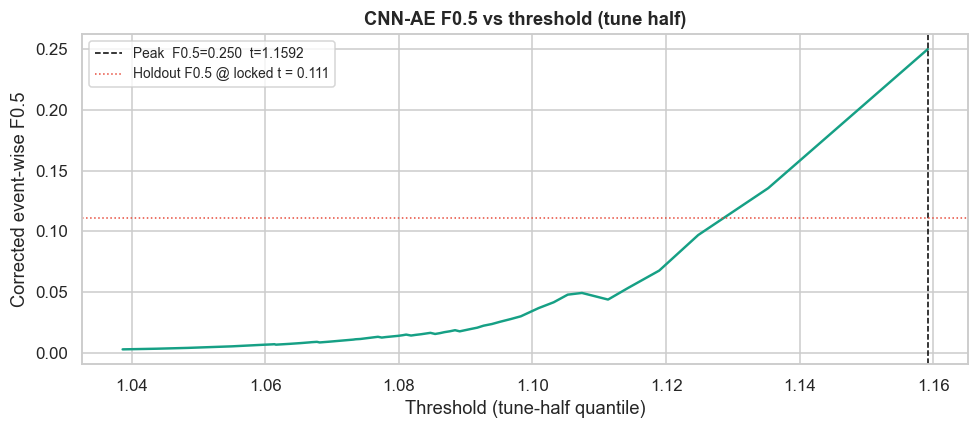

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(candidates, f05_tune, color='#16a085', lw=1.6)
ax.axvline(peak_t, color='black', ls='--', lw=1,
           label=f'Peak  F0.5={peak_f05:.3f}  t={peak_t:.4f}')
ax.axhline(hold_metric['f_score'], color=ANOMALY_COLOR, ls=':', lw=1,
           label=f'Holdout F0.5 @ locked t = {hold_metric["f_score"]:.3f}')
ax.set_xlabel('Threshold (tune-half quantile)')
ax.set_ylabel('Corrected event-wise F0.5')
ax.set_title('CNN-AE F0.5 vs threshold (tune half)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 6 — Generate Test Predictions and Save Submission

Window-level predictions from the locked (optionally fallback-corrected)
threshold, expanded to row level. Trailing test rows that don't fill a full
window inherit the last window's prediction. Submission schema is produced
with the `make_submission` helper (mirrors `notebooks/06-submission_format.ipynb`).

In [10]:
SAMPLE_SUB = RAW_DIR / 'sample_submission.parquet'


def make_submission(predictions, template_path=SAMPLE_SUB):
    '''Mirror of the helper in notebooks/06-submission_format.ipynb.'''
    template = pd.read_parquet(template_path)
    if len(predictions) != len(template):
        raise ValueError(
            f'predictions length {len(predictions)} != template length {len(template)}'
        )
    out = template.copy()
    out['is_anomaly'] = np.asarray(predictions).astype(template['is_anomaly'].dtype)
    return out


test_pred_win = (test_scores > applied_t).astype(np.uint8)
test_pred_row = np.repeat(test_pred_win, WIN)

test_df = pd.read_parquet(RAW_DIR / 'test.parquet', columns=['id'])
if len(test_pred_row) < len(test_df):
    pad = np.full(len(test_df) - len(test_pred_row), test_pred_win[-1], dtype=np.uint8)
    test_pred_row = np.concatenate([test_pred_row, pad])
test_pred_row = test_pred_row[:len(test_df)]

assert list(test_df['id']) == list(test_ids), 'ID mismatch vs processed test_ids'

submission = make_submission(test_pred_row)
submission.to_parquet(SUBMISSIONS_DIR / 'cnn_ae.parquet', index=False)

pos_rate = float(test_pred_row.mean())
n_seg    = int(np.sum(np.diff(np.concatenate([[0], test_pred_row, [0]])) == 1))
print(f'Submission saved -> submissions/cnn_ae.parquet')
print(f'Positive rate       : {pos_rate:.3%}')
print(f'Predicted segments  : {n_seg}')
if not (0.02 <= pos_rate <= 0.15):
    print(f'  WARNING: positive rate outside healthy range [2%, 15%]')
if not (10 <= n_seg <= 500):
    print(f'  WARNING: segment count outside healthy range [10, 500]')

Submission saved -> submissions/cnn_ae.parquet
Positive rate       : 0.134%
Predicted segments  : 7


---
## 7 — Compare to All Baselines

Each method's saved val scores (row-aligned to `X_val`) is run through the
same tune/holdout threshold sweep so the comparison is apples-to-apples.
Missing score files are reported as `N/A`.

In [11]:
SCORE_FILES = {
    'IForest'  : 'scores_val_iforest.npy',
    'PCA'      : 'scores_val_pca.npy',
    'LSTM-AE'  : 'scores_val_lstm_ae.npy',
    'CNN-AE'   : 'scores_val_cnn_ae.npy',
}


def sweep_and_eval(scores_row, y_row):
    '''Same tune/holdout protocol as §5: sweep on first half, evaluate on second.'''
    m = len(scores_row) // 2
    tune_s, tune_y = scores_row[:m], y_row[:m]
    hold_s, hold_y = scores_row[m:], y_row[m:]
    cand = np.quantile(tune_s, np.linspace(0.5, 0.999, 200))
    f05  = np.array([
        corrected_event_f05(tune_y, (tune_s > t).astype(np.int8))['f_score']
        for t in cand
    ], dtype=np.float32)
    t_star = float(cand[int(np.argmax(f05))])
    peak   = float(f05.max())
    hold   = corrected_event_f05(hold_y, (hold_s > t_star).astype(np.int8))['f_score']
    full   = corrected_event_f05(y_row, (scores_row > t_star).astype(np.int8))['f_score']
    return {'tune_f05': peak, 'holdout_f05': float(hold), 'full_f05': float(full), 'threshold': t_star}


rows = []
for name, fname in SCORE_FILES.items():
    path = PROCESSED_DIR / fname
    if not path.exists():
        rows.append({'Model': name, 'Tune F0.5': 'N/A', 'Holdout F0.5': 'N/A',
                     'Full val F0.5': 'N/A', 'Threshold': 'N/A'})
        continue
    s = np.load(path).astype(np.float32)
    if len(s) != len(y_val):
        rows.append({'Model': name, 'Tune F0.5': f'skip (len={len(s)})',
                     'Holdout F0.5': '-', 'Full val F0.5': '-', 'Threshold': '-'})
        continue
    r = sweep_and_eval(s, y_val)
    rows.append({
        'Model'        : name,
        'Tune F0.5'    : f'{r["tune_f05"]:.4f}',
        'Holdout F0.5' : f'{r["holdout_f05"]:.4f}',
        'Full val F0.5': f'{r["full_f05"]:.4f}',
        'Threshold'    : f'{r["threshold"]:.6f}',
    })

cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))

  Model Tune F0.5 Holdout F0.5 Full val F0.5 Threshold
IForest       N/A          N/A           N/A       N/A
    PCA    0.8332       0.1471        0.6015  0.061657
LSTM-AE    0.8332       0.1471        0.6015  0.100382
 CNN-AE    0.2499       0.1110        0.1666  1.159166


---
## Summary

Symmetric 1D-CNN autoencoder, 2 pool/up stages, bottleneck `(25, 8)`, Adam
`lr=1e-3`, MSE loss, EarlyStopping(patience=5) + ReduceLROnPlateau(patience=3).
Scoring uses channel-normalised squared error (divide by per-channel nominal
variance before summing) to prevent high-variance channels from dominating.

The §7 comparison table applies the **same tune-half / holdout-half protocol**
to each baseline's saved val scores, so every row is produced by the identical
pipeline — only the model differs. That's the measurement that matters for
picking which submission to upload.

### Artefacts produced
- `models/cnn_ae.keras`
- `data/processed/scores_val_cnn_ae.npy`
- `data/processed/scores_test_cnn_ae.npy`
- `submissions/cnn_ae.parquet`

### Drift-mitigation choices (shared with NB 05 v2)
1. **Per-window z-normalisation before the forward pass** — each window is
   centred and scaled within itself, so the model reconstructs *shape* rather
   than magnitude. Without this, the initial version of this notebook (v1) had
   a val/test max-score ratio of 284× and scored F0.5 = 0 on Kaggle because a
   zero-variance channel's numerical noise dominated the score.
2. **Top-k channel MSE (k = 5)** — the mean MSE over all 58 channels dilutes
   localised anomaly signal 58×; top-k preserves it. Most ESA-ADB anomalies
   touch only a handful of telemetry streams, so the k = 5 mean is a natural
   fit.
3. **Tune / holdout split on labelled val** — the threshold is locked on the
   first half and evaluated on the second half. A large gap between tune and
   holdout F0.5 signals that the threshold overfits the tune slice and the
   submission is at risk on Kaggle private.

### What to try next
Overlapping windows at scoring (stride < WINDOW_SIZE) would sharpen per-row
decisions for short events. Ensemble with the NB 05 (LSTM-AE) scores via
rank-averaging — the ensemble trick was the best-performing Kaggle private
run on this repo so far, so a CNN-AE + LSTM-AE rank fusion is worth trying.